In [ ]:
import os, itertools, numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef, roc_auc_score

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
print("Device:", DEVICE)

MODELS = "/kaggle/input/datasets/ajfaisal002/misleading-models"
CM_ROOT = "/kaggle/input/datasets/ajfaisal002/crossmodal-misleading-video-dataset"
CM_TXT = os.path.join(CM_ROOT, "dataset_kaggle", "extracted_text")

DIMS = {"vis": 512, "aud": 768, "txl": 768, "tqw": 1024}
SUBMAP = {"identity_fabrication":0, "perception_manipulation":1,
          "scientifically_unrealistic_scene":2, "surreal_content":3}

def sub_lookup(split):
    df = pd.read_csv(os.path.join(CM_TXT, f"{split}_metadata.csv"))
    return {str(r["video_id"]): SUBMAP.get(r["subcategory"], -1) for _, r in df.iterrows()}
sub_tr, sub_te = sub_lookup("train"), sub_lookup("test")

def load_cm(split, submap):
    d = np.load(os.path.join(MODELS, f"feats_{split}.npz"), allow_pickle=True)
    vids = [str(v) for v in d["vids"]]
    sub = np.array([submap.get(v, -1) for v in vids], dtype=np.int64)
    return {"vis_seq": torch.tensor(d["vis"]), "vis": torch.tensor(d["vis"].mean(1)),
            "aud": torch.tensor(d["aud"]), "txl": torch.tensor(d["txl"]), "tqw": torch.tensor(d["tqw"]),
            "lab": torch.tensor(d["lab"]).long(), "sub": torch.tensor(sub).long()}

def load_ft(split):
    d = np.load(os.path.join(MODELS, f"ft_{split}.npz"), allow_pickle=True)
    return {"vis_seq": torch.tensor(d["vis"]), "vis": torch.tensor(d["vis"].mean(1)),
            "aud": torch.tensor(d["aud"]), "txl": torch.tensor(d["txl"]), "tqw": torch.tensor(d["tqw"]),
            "lab": torch.tensor(d["lab"]).long()}

CM_TR, CM_TE = load_cm("train", sub_tr), load_cm("test", sub_te)
FT_TR, FT_TE = load_ft("train"), load_ft("test")

def misleading_mask(batch): return batch["sub"] >= 0

print("CM train:", CM_TR["lab"].shape[0], "| CM test:", CM_TE["lab"].shape[0])
print("FT train:", FT_TR["lab"].shape[0], "| FT test:", FT_TE["lab"].shape[0])
print("CM train sub (misleading only):", torch.bincount(CM_TR["sub"][CM_TR["sub"]>=0]).tolist())

In [4]:
class ModalityProj(nn.Module):
    def __init__(self, in_dim, out_dim=384, p=0.4):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, out_dim), nn.LayerNorm(out_dim), nn.GELU(), nn.Dropout(p))
    def forward(self, x): return self.net(x)

class TemporalAttn(nn.Module):
    def __init__(self, dim=512):
        super().__init__(); self.w = nn.Linear(dim, 1)
    def forward(self, seq):
        a = torch.softmax(self.w(seq).squeeze(-1), dim=1)
        return (a.unsqueeze(-1) * seq).sum(1)

class CrossAttn(nn.Module):
    def __init__(self, dim=384, heads=4):
        super().__init__(); self.mha = nn.MultiheadAttention(dim, heads, batch_first=True)
    def forward(self, q, kv):
        q, kv = q.unsqueeze(1), kv.unsqueeze(1)
        o, _ = self.mha(q, kv, kv)
        return o.squeeze(1)

class MultiKeyCrossAttn(nn.Module):
    def __init__(self, dim=384, heads=4):
        super().__init__(); self.mha = nn.MultiheadAttention(dim, heads, batch_first=True)
    def forward(self, q, kv_stack):
        q = q.unsqueeze(1)
        o, _ = self.mha(q, kv_stack, kv_stack)
        return o.squeeze(1)

def move(batch, idx=None):
    out = {}
    for k, v in batch.items():
        out[k] = (v[idx] if idx is not None else v).to(DEVICE)
    return out

def compute_metrics(y_true, y_pred, y_prob=None, n_classes=2):
    m = {"Accuracy": accuracy_score(y_true, y_pred)*100,
         "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0)*100,
         "MCC": matthews_corrcoef(y_true, y_pred)}
    if n_classes == 2 and y_prob is not None:
        m["ROC-AUC"] = roc_auc_score(y_true, y_prob)
    elif y_prob is not None:
        try: m["ROC-AUC"] = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
        except Exception: m["ROC-AUC"] = float("nan")
    return m

print("Cell 3 ready.")

Cell 3 ready.


In [5]:
class CrossEngine(nn.Module):
    def __init__(self, d): super().__init__(); self.cross = CrossAttn(d)
    def forward(self, mats):
        M = len(mats)
        others = sum(mats[1:]) / max(M-1,1) if M>=2 else mats[0]
        return (self.cross(mats[0], others) + mats[0]) if M>=2 else mats[0]

class QuaFusionEngine(nn.Module):
    def __init__(self, d, mods):
        super().__init__()
        self.quality_heads = nn.ModuleDict({m: nn.Sequential(nn.Linear(d,32), nn.ReLU(), nn.Linear(32,1)) for m in mods})
        self.refine = MultiKeyCrossAttn(d)
        self.mods = mods
    def forward(self, mats):
        q = torch.cat([torch.sigmoid(self.quality_heads[m](mats[i])) for i,m in enumerate(self.mods)], dim=1)
        q = torch.softmax(q, dim=1)
        f_w = sum(q[:,i:i+1]*mats[i] for i in range(len(mats)))
        stacked = torch.stack(mats, dim=1)
        return self.refine(f_w, stacked) + f_w

class CCINSAEngine(nn.Module):
    def __init__(self, d, mods):
        super().__init__()
        M = len(mods)
        self.cross_per_mod = nn.ModuleDict({m: CrossAttn(d) for m in mods})
        self.agg_wgt = nn.Linear(d*M, M)
        self.mods = mods
    def forward(self, mats):
        M = len(mats)
        c_list = []
        for i, m in enumerate(self.mods):
            other_mean = sum(mats[j] for j in range(M) if j!=i) / max(M-1,1)
            c_list.append(self.cross_per_mod[m](mats[i], other_mean) + mats[i])
        cat_c = torch.cat(c_list, dim=-1)
        w = torch.softmax(self.agg_wgt(cat_c), dim=-1)
        return sum(w[:,i:i+1]*c_list[i] for i in range(M))

class AmbiguityEngine(nn.Module):
    def __init__(self, d, mods):
        super().__init__()
        M = len(mods)
        n_pairs = M*(M-1)//2
        self.amb_mlp = nn.Sequential(nn.Linear(n_pairs,32), nn.ReLU(), nn.Linear(32,M))
        self.base_cross = CrossAttn(d) if M>=2 else None
    def forward(self, mats):
        M = len(mats)
        pairs = []
        for i in range(M):
            for j in range(i+1,M):
                pairs.append((1-F.cosine_similarity(mats[i],mats[j],dim=-1,eps=1e-8)).unsqueeze(1))
        amb_stack = torch.cat(pairs, dim=1)
        adj = torch.softmax(self.amb_mlp(amb_stack), dim=1)
        f_w = sum(adj[:,i:i+1]*mats[i] for i in range(M))
        others = sum(mats[1:])/max(M-1,1) if M>=2 else mats[0]
        base = (self.base_cross(mats[0], others)+mats[0]) if M>=2 else mats[0]
        return base + f_w

class AtCAFEngine(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.cross_obs = CrossAttn(d)
        self.cross_spurious = CrossAttn(d)
        self.lambda_causal = nn.Parameter(torch.tensor(0.0))
    def forward(self, mats):
        M = len(mats)
        others = sum(mats[1:])/max(M-1,1) if M>=2 else mats[0]
        if M < 2: return mats[0]
        F_obs = self.cross_obs(mats[0], others) + mats[0]
        perm = torch.randperm(others.size(0), device=others.device)
        F_spurious = self.cross_spurious(mats[0], others[perm])
        return F_obs - torch.sigmoid(self.lambda_causal) * F_spurious

ENGINE_REGISTRY = {
    "cross": lambda d, mods: CrossEngine(d),
    "quafusion": lambda d, mods: QuaFusionEngine(d, mods),
    "ccinsa": lambda d, mods: CCINSAEngine(d, mods),
    "ambiguity": lambda d, mods: AmbiguityEngine(d, mods),
    "atcaf": lambda d, mods: AtCAFEngine(d),
}
print("Engine registry ready:", list(ENGINE_REGISTRY.keys()))

Engine registry ready: ['cross', 'quafusion', 'ccinsa', 'ambiguity', 'atcaf']


In [6]:
class CombinedFusionModel(nn.Module):
    """Runs a chosen subset of fusion mechanisms in parallel, then learns to combine their outputs."""
    def __init__(self, mods, engine_names, d=384, dropout=0.4, n_classes=2, use_temporal=True):
        super().__init__()
        self.mods, self.d, self.use_temporal = mods, d, use_temporal
        self.engine_names = engine_names
        if "vis" in mods and use_temporal:
            self.tattn = TemporalAttn(512)
        self.proj = nn.ModuleDict({m: ModalityProj(DIMS[m], d, dropout) for m in mods})
        self.engines = nn.ModuleList([ENGINE_REGISTRY[name](d, mods) for name in engine_names])
        # learned combination weights across the K engine outputs
        self.combine_wgt = nn.Linear(d*len(engine_names), len(engine_names))
        self.head = nn.Sequential(nn.Linear(d,128), nn.LayerNorm(128), nn.GELU(),
                                  nn.Dropout(dropout), nn.Linear(128, n_classes))

    def encode(self, batch):
        feats = {}
        for m in self.mods:
            feats[m] = self.proj[m](self.tattn(batch["vis_seq"])) if (m=="vis" and self.use_temporal) else self.proj[m](batch[m])
        return feats

    def forward(self, batch):
        f = self.encode(batch)
        mats = [f[m] for m in self.mods]
        outs = [engine(mats) for engine in self.engines]   # K x (B,d)
        cat = torch.cat(outs, dim=-1)
        w = torch.softmax(self.combine_wgt(cat), dim=-1)    # (B,K)
        fused = sum(w[:, i:i+1] * outs[i] for i in range(len(outs)))
        return self.head(fused)

def train_eval_combined(mods, engine_names, train, evalset, n_classes=2, label_key="lab",
                        d=384, dropout=0.4, lr=2e-3, wd=1e-2, epochs=60, bs=64,
                        use_temporal=True, seed=SEED, filter_fn=None):
    torch.manual_seed(seed); np.random.seed(seed)
    model = CombinedFusionModel(mods, engine_names, d=d, dropout=dropout, n_classes=n_classes,
                                use_temporal=use_temporal).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    lossf = nn.CrossEntropyLoss()
    tr = train
    if filter_fn is not None:
        mask = filter_fn(tr); tr = {k:v[mask] for k,v in tr.items()}
    N = tr[label_key].shape[0]; idx_all = np.arange(N)
    for ep in range(epochs):
        model.train(); np.random.shuffle(idx_all)
        for s in range(0,N,bs):
            b = move(tr, idx_all[s:s+bs])
            loss = lossf(model(b), b[label_key])
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()
    ev = evalset
    if filter_fn is not None:
        mask = filter_fn(ev); ev = {k:v[mask] for k,v in ev.items()}
    model.eval()
    with torch.no_grad():
        b = move(ev); logits = model(b)
        prob = torch.softmax(logits,1).cpu().numpy()
        pred = logits.argmax(1).cpu().numpy(); true = ev[label_key].numpy()
    prob_auc = prob[:,1] if n_classes==2 else prob
    return compute_metrics(true, pred, prob_auc, n_classes), model

print("CombinedFusionModel ready.")

CombinedFusionModel ready.


In [ ]:
print("=== Stage 1: Combined Fusion Mechanisms ===\n")

combos = {
    "Cross + Ambiguity":            ["cross", "ambiguity"],
    "Cross + CCIN-SA":              ["cross", "ccinsa"],
    "Ambiguity + AtCAF":            ["ambiguity", "atcaf"],
    "Cross + QuaFusion + Ambiguity":["cross", "quafusion", "ambiguity"],
    "All five":                     ["cross", "quafusion", "ccinsa", "ambiguity", "atcaf"],
}

for name, engines in combos.items():
    m, _ = train_eval_combined(["vis","aud","txl","tqw"], engines, CM_TR, CM_TE,
                               n_classes=2, label_key="lab", d=384, dropout=0.4,
                               lr=2e-3, wd=1e-2, epochs=60)
    print(f"  {name:32s} Acc={m['Accuracy']:.2f}  MacroF1={m['Macro F1']:.2f}  "
          f"AUC={m['ROC-AUC']:.3f}  MCC={m['MCC']:.3f}")

print("\nReference (single mechanisms, Stage 1):")
print("  Cross-Attention alone: 87.71")
print("  Ambiguity alone:       86.50")

In [ ]:
print("=== Stage 2: Combined Fusion Mechanisms ===\n")

for name, engines in combos.items():
    m, _ = train_eval_combined(["vis","aud","txl","tqw"], engines, CM_TR, CM_TE,
                               n_classes=4, label_key="sub", d=384, dropout=0.4,
                               lr=2e-3, wd=1e-2, epochs=60, filter_fn=misleading_mask)
    print(f"  {name:32s} Acc={m['Accuracy']:.2f}  MacroF1={m['Macro F1']:.2f}  MCC={m['MCC']:.3f}")

print("\nReference (single mechanisms, Stage 2):")
print("  Ambiguity-aware alone: 84.17 (best single)")
print("  Cross-Attention alone: 82.25")

print("=== FakeTT: Combined Fusion Mechanisms ===\n")

for name, engines in combos.items():
    m, _ = train_eval_combined(["vis","aud","txl","tqw"], engines, FT_TR, FT_TE,
                               n_classes=2, label_key="lab", d=384, dropout=0.4,
                               lr=2e-3, wd=1e-2, epochs=60)
    print(f"  {name:32s} Acc={m['Accuracy']:.2f}  MacroF1={m['Macro F1']:.2f}  "
          f"AUC={m['ROC-AUC']:.3f}  MCC={m['MCC']:.3f}")

print("\nReference (single mechanisms, FakeTT):")
print("  Ambiguity-aware alone: 84.80 (best single)")
print("  Cross-Attention alone: 83.63")

In [8]:
def multi_seed_combined(engines, train, test, n_classes, label_key, filter_fn=None, seeds=(42,43,44)):
    accs, f1s, mccs, aucs = [], [], [], []
    for s in seeds:
        m, _ = train_eval_combined(["vis","aud","txl","tqw"], engines, train, test,
                                   n_classes=n_classes, label_key=label_key, d=384, dropout=0.4,
                                   lr=2e-3, wd=1e-2, epochs=60, filter_fn=filter_fn, seed=s)
        accs.append(m["Accuracy"]); f1s.append(m["Macro F1"]); mccs.append(m["MCC"])
        if "ROC-AUC" in m: aucs.append(m["ROC-AUC"])
    out = {"acc_mean": np.mean(accs), "acc_std": np.std(accs),
           "f1_mean": np.mean(f1s), "mcc_mean": np.mean(mccs)}
    if aucs: out["auc_mean"] = np.mean(aucs)
    return out

# print("=== FakeTT: 3-seed verification ===\n")

# r1 = multi_seed_combined(["ambiguity","atcaf"], FT_TR, FT_TE, 2, "lab")
# print(f"  Ambiguity + AtCAF   Acc={r1['acc_mean']:.2f}±{r1['acc_std']:.2f}  "
#       f"MacroF1={r1['f1_mean']:.2f}  AUC={r1.get('auc_mean',float('nan')):.3f}  MCC={r1['mcc_mean']:.3f}")

# r2 = multi_seed_combined(["ambiguity"], FT_TR, FT_TE, 2, "lab")
# print(f"  Ambiguity alone     Acc={r2['acc_mean']:.2f}±{r2['acc_std']:.2f}  "
#       f"MacroF1={r2['f1_mean']:.2f}  AUC={r2.get('auc_mean',float('nan')):.3f}  MCC={r2['mcc_mean']:.3f}")

# print(f"\nGap: {r1['acc_mean']-r2['acc_mean']:+.2f} pts (combined std: "
#       f"{(r1['acc_std']**2 + r2['acc_std']**2)**0.5:.2f})")

In [9]:
class AmbiguityEngine(nn.Module):
    def __init__(self, d, mods):
        super().__init__()
        M = len(mods)
        self.M = M
        if M >= 2:
            n_pairs = M*(M-1)//2
            self.amb_mlp = nn.Sequential(nn.Linear(n_pairs,32), nn.ReLU(), nn.Linear(32,M))
            self.base_cross = CrossAttn(d)
    def forward(self, mats):
        M = len(mats)
        if M < 2:
            return mats[0]   # no pairwise ambiguity possible with one modality
        pairs = []
        for i in range(M):
            for j in range(i+1,M):
                pairs.append((1-F.cosine_similarity(mats[i],mats[j],dim=-1,eps=1e-8)).unsqueeze(1))
        amb_stack = torch.cat(pairs, dim=1)
        adj = torch.softmax(self.amb_mlp(amb_stack), dim=1)
        f_w = sum(adj[:,i:i+1]*mats[i] for i in range(M))
        others = sum(mats[1:])/max(M-1,1)
        base = self.base_cross(mats[0], others) + mats[0]
        return base + f_w

ENGINE_REGISTRY["ambiguity"] = lambda d, mods: AmbiguityEngine(d, mods)
print("AmbiguityEngine patched for unimodal safety.")

AmbiguityEngine patched for unimodal safety.


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

print("=== Stage 1 (Ambiguity-aware) — Test ===\n")
m1, model1 = train_eval_combined(["vis","aud","txl","tqw"], ["ambiguity"], CM_TR, CM_TE,
                                 n_classes=2, label_key="lab", d=384, dropout=0.4,
                                 lr=2e-3, wd=1e-2, epochs=60)
for k,v in m1.items(): print(f"  {k}: {v:.3f}" if k in ("MCC","ROC-AUC") else f"  {k}: {v:.2f}")

print("\n=== Stage 1 — 5-fold CV ===\n")
y1 = CM_TR["lab"].numpy()
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
folds1 = []
for fold,(tri,vai) in enumerate(skf.split(np.zeros(len(y1)),y1),1):
    trF = {k:v[tri] for k,v in CM_TR.items()}; vaF = {k:v[vai] for k,v in CM_TR.items()}
    m,_ = train_eval_combined(["vis","aud","txl","tqw"], ["ambiguity"], trF, vaF,
                              n_classes=2, label_key="lab", d=384, dropout=0.4,
                              lr=2e-3, wd=1e-2, epochs=60, seed=SEED+fold)
    folds1.append(m)
    print(f"  Fold {fold}: Acc={m['Accuracy']:.2f}  MacroF1={m['Macro F1']:.2f}  MCC={m['MCC']:.3f}")
for k in ["Accuracy","Macro F1","MCC","ROC-AUC"]:
    vals = np.array([f[k] for f in folds1])
    print(f"  Mean {k}: {vals.mean():.3f} ± {vals.std():.3f}")

In [ ]:
print("=== Stage 2 (Ambiguity-aware) — Test ===\n")
m2, model2 = train_eval_combined(["vis","aud","txl","tqw"], ["ambiguity"], CM_TR, CM_TE,
                                 n_classes=4, label_key="sub", d=384, dropout=0.4,
                                 lr=2e-3, wd=1e-2, epochs=60, filter_fn=misleading_mask)
for k,v in m2.items(): print(f"  {k}: {v:.3f}" if k in ("MCC","ROC-AUC") else f"  {k}: {v:.2f}")

# per-class report + confusion matrix
model2.eval()
mis_te = {k:v[misleading_mask(CM_TE)] for k,v in CM_TE.items()}
with torch.no_grad():
    logits = model2(move(mis_te))
    pred2 = logits.argmax(1).cpu().numpy()
true2 = mis_te["sub"].numpy()
SUBNAMES = ["IF","PM","SUS","SC"]
print("\nPer-class report:")
print(classification_report(true2, pred2, target_names=SUBNAMES, digits=3))
print("Confusion matrix (rows=true, cols=pred), order IF,PM,SUS,SC:")
print(confusion_matrix(true2, pred2))

print("\n=== Stage 2 — 5-fold CV ===\n")
mis_mask_tr = misleading_mask(CM_TR).numpy()
CM_TR_MIS = {k:v[torch.tensor(mis_mask_tr)] for k,v in CM_TR.items()}
y2 = CM_TR_MIS["sub"].numpy()
skf2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
folds2 = []
for fold,(tri,vai) in enumerate(skf2.split(np.zeros(len(y2)),y2),1):
    trF = {k:v[tri] for k,v in CM_TR_MIS.items()}; vaF = {k:v[vai] for k,v in CM_TR_MIS.items()}
    m,_ = train_eval_combined(["vis","aud","txl","tqw"], ["ambiguity"], trF, vaF,
                              n_classes=4, label_key="sub", d=384, dropout=0.4,
                              lr=2e-3, wd=1e-2, epochs=60, seed=SEED+fold)
    folds2.append(m)
    print(f"  Fold {fold}: Acc={m['Accuracy']:.2f}  MacroF1={m['Macro F1']:.2f}  MCC={m['MCC']:.3f}")
for k in ["Accuracy","Macro F1","MCC"]:
    vals = np.array([f[k] for f in folds2])
    print(f"  Mean {k}: {vals.mean():.3f} ± {vals.std():.3f}")

In [ ]:
print("=== Hierarchical Cascade (Ambiguity-aware) ===\n")
model1.eval(); model2.eval()
with torch.no_grad():
    pred1 = model1(move(CM_TE)).argmax(1).cpu().numpy()
true1 = CM_TE["lab"].numpy()
true_sub = CM_TE["sub"].numpy()

final_pred = np.full(len(true1), -1)
mis_idx = np.where(pred1 == 1)[0]
if len(mis_idx) > 0:
    sub_batch = {k: v[mis_idx] for k, v in CM_TE.items()}
    with torch.no_grad():
        pred2c = model2(move(sub_batch)).argmax(1).cpu().numpy()
    final_pred[mis_idx] = pred2c

def to_unified(binary_lab, sub_lab):
    out = np.zeros(len(binary_lab), dtype=int)
    for i in range(len(binary_lab)):
        out[i] = 0 if binary_lab[i]==0 else sub_lab[i]+1
    return out

true_unified = to_unified(true1, true_sub)
pred_unified = np.where(final_pred==-1, 0, final_pred+1)
unified_names = ["Safe","IF","PM","SUS","SC"]

print(classification_report(true_unified, pred_unified, target_names=unified_names, digits=3, zero_division=0))
print(f"Overall hierarchical accuracy: {accuracy_score(true_unified, pred_unified)*100:.2f}%")
print(f"Overall hierarchical Macro F1: {f1_score(true_unified, pred_unified, average='macro', zero_division=0)*100:.2f}%")

In [ ]:
print("=== FakeTT (Ambiguity-aware) — Test ===\n")
mft, model_ft = train_eval_combined(["vis","aud","txl","tqw"], ["ambiguity"], FT_TR, FT_TE,
                                    n_classes=2, label_key="lab", d=384, dropout=0.4,
                                    lr=2e-3, wd=1e-2, epochs=60)
for k,v in mft.items(): print(f"  {k}: {v:.3f}" if k in ("MCC","ROC-AUC") else f"  {k}: {v:.2f}")

print("\n=== FakeTT — 5-fold CV ===\n")
yft = FT_TR["lab"].numpy()
skf_ft = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
foldsft = []
for fold,(tri,vai) in enumerate(skf_ft.split(np.zeros(len(yft)),yft),1):
    trF = {k:v[tri] for k,v in FT_TR.items()}; vaF = {k:v[vai] for k,v in FT_TR.items()}
    m,_ = train_eval_combined(["vis","aud","txl","tqw"], ["ambiguity"], trF, vaF,
                              n_classes=2, label_key="lab", d=384, dropout=0.4,
                              lr=2e-3, wd=1e-2, epochs=60, seed=SEED+fold)
    foldsft.append(m)
    print(f"  Fold {fold}: Acc={m['Accuracy']:.2f}  MacroF1={m['Macro F1']:.2f}  MCC={m['MCC']:.3f}")
for k in ["Accuracy","Macro F1","MCC","ROC-AUC"]:
    vals = np.array([f[k] for f in foldsft])
    print(f"  Mean {k}: {vals.mean():.3f} ± {vals.std():.3f}")

In [ ]:
def run_combo(mods, tr, te, n_classes, label_key, filter_fn=None):
    m,_ = train_eval_combined(mods, ["ambiguity"], tr, te, n_classes=n_classes, label_key=label_key,
                              d=384, dropout=0.4, lr=2e-3, wd=1e-2, epochs=60,
                              filter_fn=filter_fn, use_temporal=("vis" in mods))
    return m

print("=== Stage 1: Unimodal / Bimodal / Trimodal (Ambiguity-aware) ===\n")
combos_s1 = {"CLIP":["vis"],"Wav2Vec2":["aud"],"XLM-R":["txl"],"Qwen":["tqw"],
             "CLIP+Wav2Vec2":["vis","aud"],"CLIP+XLM-R+Qwen":["vis","txl","tqw"],
             "Wav2Vec2+XLM-R+Qwen":["aud","txl","tqw"],"All four":["vis","aud","txl","tqw"]}
for name, mods in combos_s1.items():
    m = run_combo(mods, CM_TR, CM_TE, 2, "lab")
    print(f"  {name:24s} Acc={m['Accuracy']:.2f}  MacroF1={m['Macro F1']:.2f}  MCC={m['MCC']:.3f}")

print("\n=== Stage 2: Unimodal / Bimodal / Trimodal (Ambiguity-aware) ===\n")
for name, mods in combos_s1.items():
    m = run_combo(mods, CM_TR, CM_TE, 4, "sub", filter_fn=misleading_mask)
    print(f"  {name:24s} Acc={m['Accuracy']:.2f}  MacroF1={m['Macro F1']:.2f}  MCC={m['MCC']:.3f}")

print("\n=== Stage 1 Ablation (drop one modality from full Ambiguity model) ===\n")
abl = {"Full":["vis","aud","txl","tqw"],"w/o Audio":["vis","txl","tqw"],
       "w/o Vision":["aud","txl","tqw"],"w/o Text":["vis","aud"]}
for name, mods in abl.items():
    m = run_combo(mods, CM_TR, CM_TE, 2, "lab")
    print(f"  {name:14s} Acc={m['Accuracy']:.2f}  MacroF1={m['Macro F1']:.2f}  MCC={m['MCC']:.3f}")

print("\n=== Stage 2 Ablation ===\n")
for name, mods in abl.items():
    m = run_combo(mods, CM_TR, CM_TE, 4, "sub", filter_fn=misleading_mask)
    print(f"  {name:14s} Acc={m['Accuracy']:.2f}  MacroF1={m['Macro F1']:.2f}  MCC={m['MCC']:.3f}")

In [10]:
class PureEngineModel(nn.Module):
    """Runs exactly one fusion engine, no combine_wgt wrapper — the true single-mechanism architecture."""
    def __init__(self, mods, engine_name, d=384, dropout=0.4, n_classes=2, use_temporal=True):
        super().__init__()
        self.mods, self.d, self.use_temporal = mods, d, use_temporal
        if "vis" in mods and use_temporal:
            self.tattn = TemporalAttn(512)
        self.proj = nn.ModuleDict({m: ModalityProj(DIMS[m], d, dropout) for m in mods})
        self.engine = ENGINE_REGISTRY[engine_name](d, mods)
        self.head = nn.Sequential(nn.Linear(d,128), nn.LayerNorm(128), nn.GELU(),
                                  nn.Dropout(dropout), nn.Linear(128, n_classes))

    def encode(self, batch):
        feats = {}
        for m in self.mods:
            feats[m] = self.proj[m](self.tattn(batch["vis_seq"])) if (m=="vis" and self.use_temporal) else self.proj[m](batch[m])
        return feats

    def forward(self, batch):
        f = self.encode(batch)
        mats = [f[m] for m in self.mods]
        fused = self.engine(mats)
        return self.head(fused)

def train_eval_pure(mods, engine_name, train, evalset, n_classes=2, label_key="lab",
                    d=384, dropout=0.4, lr=2e-3, wd=1e-2, epochs=60, bs=64,
                    use_temporal=True, seed=SEED, filter_fn=None):
    torch.manual_seed(seed); np.random.seed(seed)
    model = PureEngineModel(mods, engine_name, d=d, dropout=dropout, n_classes=n_classes,
                            use_temporal=use_temporal).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    lossf = nn.CrossEntropyLoss()
    tr = train
    if filter_fn is not None:
        mask = filter_fn(tr); tr = {k:v[mask] for k,v in tr.items()}
    N = tr[label_key].shape[0]; idx_all = np.arange(N)
    for ep in range(epochs):
        model.train(); np.random.shuffle(idx_all)
        for s in range(0,N,bs):
            b = move(tr, idx_all[s:s+bs])
            loss = lossf(model(b), b[label_key])
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()
    ev = evalset
    if filter_fn is not None:
        mask = filter_fn(ev); ev = {k:v[mask] for k,v in ev.items()}
    model.eval()
    with torch.no_grad():
        b = move(ev); logits = model(b)
        prob = torch.softmax(logits,1).cpu().numpy()
        pred = logits.argmax(1).cpu().numpy(); true = ev[label_key].numpy()
    prob_auc = prob[:,1] if n_classes==2 else prob
    m = compute_metrics(true, pred, prob_auc, n_classes)
    return m, model, (true, pred, prob)

print("PureEngineModel ready.")


print("=== Stage 2 (pure Ambiguity-aware, reconciliation run) ===\n")
m2b, model2b, (true2b, pred2b, prob2b) = train_eval_pure(
    ["vis","aud","txl","tqw"], "ambiguity", CM_TR, CM_TE,
    n_classes=4, label_key="sub", d=384, dropout=0.4,
    lr=2e-3, wd=1e-2, epochs=60, filter_fn=misleading_mask
)
for k,v in m2b.items(): print(f"  {k}: {v:.3f}" if k in ("MCC","ROC-AUC") else f"  {k}: {v:.2f}")

print("\nPer-class report:")
print(classification_report(true2b, pred2b, target_names=SUBNAMES, digits=3))
print("Confusion matrix (IF,PM,SUS,SC):")
print(confusion_matrix(true2b, pred2b))

PureEngineModel ready.
=== Stage 2 (pure Ambiguity-aware, reconciliation run) ===

  Accuracy: 84.00
  Macro F1: 84.12
  MCC: 0.789
  ROC-AUC: 0.967

Per-class report:


NameError: name 'classification_report' is not defined

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import numpy as np, torch

SUBNAMES = ["IF", "PM", "SUS", "SC"]

# ---------------------------------------------------------------
# Stage 1 — pure Ambiguity-aware (reconciliation)
# ---------------------------------------------------------------
print("=== Stage 1 (pure Ambiguity-aware) ===\n")
m1b, model1b, _ = train_eval_pure(
    ["vis","aud","txl","tqw"], "ambiguity", CM_TR, CM_TE,
    n_classes=2, label_key="lab", d=384, dropout=0.4,
    lr=2e-3, wd=1e-2, epochs=60
)
for k, v in m1b.items():
    print(f"  {k}: {v:.3f}" if k in ("MCC","ROC-AUC") else f"  {k}: {v:.2f}")

# ---------------------------------------------------------------
# Stage 2 — pure Ambiguity-aware (reconciliation)
# ---------------------------------------------------------------
print("\n=== Stage 2 (pure Ambiguity-aware) ===\n")
m2b, model2b, (true2b, pred2b, prob2b) = train_eval_pure(
    ["vis","aud","txl","tqw"], "ambiguity", CM_TR, CM_TE,
    n_classes=4, label_key="sub", d=384, dropout=0.4,
    lr=2e-3, wd=1e-2, epochs=60, filter_fn=misleading_mask
)
for k, v in m2b.items():
    print(f"  {k}: {v:.3f}" if k in ("MCC","ROC-AUC") else f"  {k}: {v:.2f}")

print("\nPer-class report:")
print(classification_report(true2b, pred2b, target_names=SUBNAMES, digits=3))
print("Confusion matrix (rows=true, cols=pred), order IF,PM,SUS,SC:")
print(confusion_matrix(true2b, pred2b))

# ---------------------------------------------------------------
# Hierarchical cascade (chained Stage 1 -> Stage 2, both pure models)
# ---------------------------------------------------------------
print("\n=== Hierarchical Cascade (pure Ambiguity-aware, both stages) ===\n")
model1b.eval(); model2b.eval()
with torch.no_grad():
    pred1 = model1b(move(CM_TE)).argmax(1).cpu().numpy()
true1 = CM_TE["lab"].numpy()
true_sub = CM_TE["sub"].numpy()

final_pred = np.full(len(true1), -1)
mis_idx = np.where(pred1 == 1)[0]
if len(mis_idx) > 0:
    sub_batch = {k: v[mis_idx] for k, v in CM_TE.items()}
    with torch.no_grad():
        pred2c = model2b(move(sub_batch)).argmax(1).cpu().numpy()
    final_pred[mis_idx] = pred2c

def to_unified(binary_lab, sub_lab):
    out = np.zeros(len(binary_lab), dtype=int)
    for i in range(len(binary_lab)):
        out[i] = 0 if binary_lab[i] == 0 else sub_lab[i] + 1
    return out

true_unified = to_unified(true1, true_sub)
pred_unified = np.where(final_pred == -1, 0, final_pred + 1)
unified_names = ["Safe","IF","PM","SUS","SC"]

print(classification_report(true_unified, pred_unified, target_names=unified_names, digits=3, zero_division=0))
print(f"Overall hierarchical accuracy: {accuracy_score(true_unified, pred_unified)*100:.2f}%")
print(f"Overall hierarchical Macro F1: {f1_score(true_unified, pred_unified, average='macro', zero_division=0)*100:.2f}%")

print("\n\nDONE — all three sections reconciled with the pure single-mechanism (Ambiguity-aware) architecture.")

=== Stage 1 (pure Ambiguity-aware) ===

  Accuracy: 85.75
  Macro F1: 85.75
  MCC: 0.715
  ROC-AUC: 0.932

=== Stage 2 (pure Ambiguity-aware) ===

  Accuracy: 84.00
  Macro F1: 84.12
  MCC: 0.789
  ROC-AUC: 0.967

Per-class report:
              precision    recall  f1-score   support

          IF      0.830     0.830     0.830       100
          PM      0.771     0.810     0.790       100
         SUS      0.800     0.920     0.856       100
          SC      1.000     0.800     0.889       100

    accuracy                          0.840       400
   macro avg      0.850     0.840     0.841       400
weighted avg      0.850     0.840     0.841       400

Confusion matrix (rows=true, cols=pred), order IF,PM,SUS,SC:
[[83 14  3  0]
 [15 81  4  0]
 [ 1  7 92  0]
 [ 1  3 16 80]]

=== Hierarchical Cascade (pure Ambiguity-aware, both stages) ===

              precision    recall  f1-score   support

        Safe      0.865     0.848     0.856       400
          IF      0.659     0.580  

Saved fusion_stage1.png and fusion_stage1.pdf


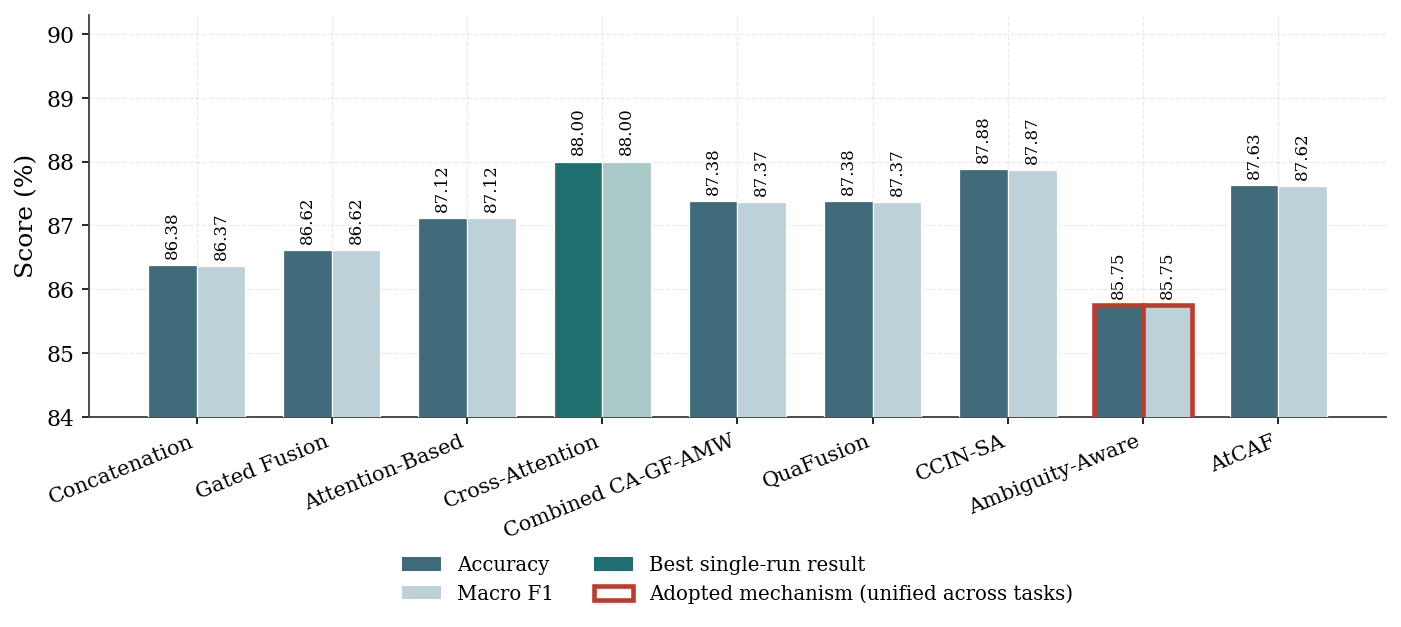

In [16]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.patches import Patch

mpl.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 600,
    "font.family": "serif", "font.serif": ["Georgia", "Times New Roman", "DejaVu Serif"],
    "font.size": 12, "axes.titlesize": 13, "axes.labelsize": 12,
    "xtick.labelsize": 10, "ytick.labelsize": 10.5,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6, "grid.linestyle": "--",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#444444", "axes.linewidth": 0.9,
    "legend.frameon": False, "savefig.bbox": "tight", "savefig.facecolor": "white",
})

DARK_TEAL = "#1f6f6f"
LIGHT_TEAL = "#a9c9c9"
DARK_STD = "#3f6b7a"
LIGHT_STD = "#bcd2d8"
ADOPT_EDGE = "#c0392b"

data = {
    "Concatenation":       [86.38, 86.37],
    "Gated Fusion":        [86.62, 86.62],
    "Attention-Based":     [87.12, 87.12],
    "Cross-Attention":     [88.00, 88.00],
    "Combined CA-GF-AMW":  [87.38, 87.37],
    "QuaFusion":           [87.38, 87.37],
    "CCIN-SA":             [87.88, 87.87],
    "Ambiguity-Aware":     [85.75, 85.75],
    "AtCAF":               [87.63, 87.62],
}

labels = list(data.keys())
acc = [data[k][0] for k in labels]
f1  = [data[k][1] for k in labels]
x = np.arange(len(labels)); w = 0.36

best_key = "Cross-Attention"
adopted_key = "Ambiguity-Aware"

# NO title on the figure itself — this goes in \caption{} in LaTeX instead
fig, ax = plt.subplots(figsize=(9.5, 4.6))

acc_colors = [DARK_TEAL if k == best_key else DARK_STD for k in labels]
f1_colors  = [LIGHT_TEAL if k == best_key else LIGHT_STD for k in labels]

bars_acc = ax.bar(x - w/2, acc, w, color=acc_colors, edgecolor="white", linewidth=0.6, zorder=3)
bars_f1  = ax.bar(x + w/2, f1,  w, color=f1_colors,  edgecolor="white", linewidth=0.6, zorder=3)

for i, k in enumerate(labels):
    if k == adopted_key:
        bars_acc[i].set_edgecolor(ADOPT_EDGE); bars_acc[i].set_linewidth(2.2)
        bars_f1[i].set_edgecolor(ADOPT_EDGE);  bars_f1[i].set_linewidth(2.2)

# ---- fixed value labels: rotated 90°, placed just above each individual bar ----
for i in range(len(labels)):
    ax.text(x[i]-w/2, acc[i]+0.10, f"{acc[i]:.2f}", ha="center", va="bottom",
            fontsize=8, rotation=90)
    ax.text(x[i]+w/2, f1[i]+0.10,  f"{f1[i]:.2f}",  ha="center", va="bottom",
            fontsize=8, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=22, ha="right")
ax.set_ylabel("Score (%)")
ax.set_ylim(84, 90.3)   # extra headroom for the taller rotated labels
ax.set_axisbelow(True)

legend_handles = [
    Patch(facecolor=DARK_STD, label="Accuracy"),
    Patch(facecolor=LIGHT_STD, label="Macro F1"),
    Patch(facecolor=DARK_TEAL, label="Best single-run result"),
    Patch(facecolor="white", edgecolor=ADOPT_EDGE, linewidth=2.2, label="Adopted mechanism (unified across tasks)"),
]
ax.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.30),
          ncol=2, frameon=False, fontsize=9.5)

plt.rcParams["savefig.dpi"] = 600

fig.tight_layout()
fig.savefig("fusion_stage1.png")
fig.savefig("fusion_stage1.pdf")
print("Saved fusion_stage1.png and fusion_stage1.pdf")

Saved fusion_stage2.png and fusion_stage2.pdf


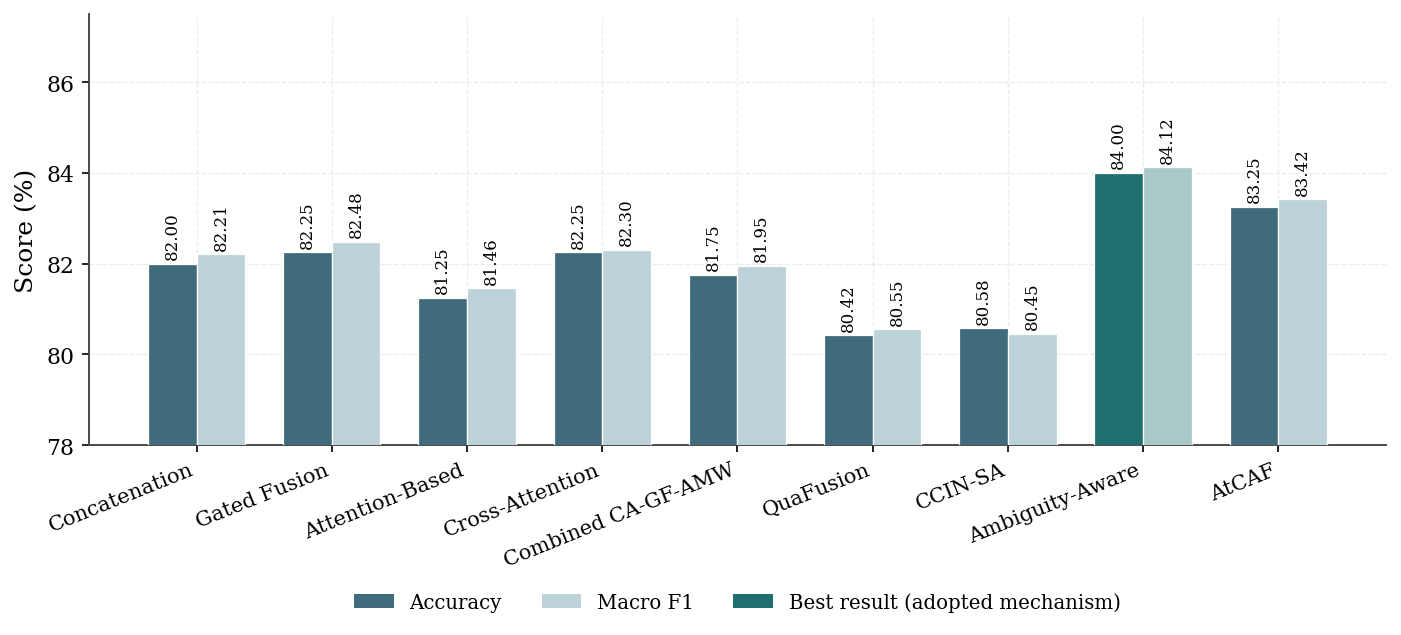

In [17]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.patches import Patch

mpl.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 600,
    "font.family": "serif", "font.serif": ["Georgia", "Times New Roman", "DejaVu Serif"],
    "font.size": 12, "axes.titlesize": 13, "axes.labelsize": 12,
    "xtick.labelsize": 10, "ytick.labelsize": 10.5,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6, "grid.linestyle": "--",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#444444", "axes.linewidth": 0.9,
    "legend.frameon": False, "savefig.bbox": "tight", "savefig.facecolor": "white",
})

DARK_TEAL = "#1f6f6f"
LIGHT_TEAL = "#a9c9c9"
DARK_STD = "#3f6b7a"
LIGHT_STD = "#bcd2d8"

# ---- real reconciled Stage 2 fusion comparison numbers ----
data = {
    "Concatenation":       [82.00, 82.21],
    "Gated Fusion":        [82.25, 82.48],
    "Attention-Based":     [81.25, 81.46],
    "Cross-Attention":     [82.25, 82.30],
    "Combined CA-GF-AMW":  [81.75, 81.95],
    "QuaFusion":           [80.42, 80.55],
    "CCIN-SA":             [80.58, 80.45],
    "Ambiguity-Aware":     [84.00, 84.12],
    "AtCAF":               [83.25, 83.42],
}

labels = list(data.keys())
acc = [data[k][0] for k in labels]
f1  = [data[k][1] for k in labels]
x = np.arange(len(labels)); w = 0.36

best_key = "Ambiguity-Aware"   # numeric winner AND adopted mechanism for this task

fig, ax = plt.subplots(figsize=(9.5, 4.6))

acc_colors = [DARK_TEAL if k == best_key else DARK_STD for k in labels]
f1_colors  = [LIGHT_TEAL if k == best_key else LIGHT_STD for k in labels]

bars_acc = ax.bar(x - w/2, acc, w, color=acc_colors, edgecolor="white", linewidth=0.6, zorder=3)
bars_f1  = ax.bar(x + w/2, f1,  w, color=f1_colors,  edgecolor="white", linewidth=0.6, zorder=3)

for i in range(len(labels)):
    ax.text(x[i]-w/2, acc[i]+0.10, f"{acc[i]:.2f}", ha="center", va="bottom",
            fontsize=8, rotation=90)
    ax.text(x[i]+w/2, f1[i]+0.10,  f"{f1[i]:.2f}",  ha="center", va="bottom",
            fontsize=8, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=22, ha="right")
ax.set_ylabel("Score (%)")
ax.set_ylim(78, 87.5)
ax.set_axisbelow(True)

legend_handles = [
    Patch(facecolor=DARK_STD, label="Accuracy"),
    Patch(facecolor=LIGHT_STD, label="Macro F1"),
    Patch(facecolor=DARK_TEAL, label="Best result (adopted mechanism)"),
]
ax.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.30),
          ncol=3, frameon=False, fontsize=9.5)

plt.rcParams["savefig.dpi"] = 600

fig.tight_layout()
fig.savefig("fusion_stage2.png")
fig.savefig("fusion_stage2.pdf")
print("Saved fusion_stage2.png and fusion_stage2.pdf")

Saved cm_stage2.png and cm_stage2.pdf


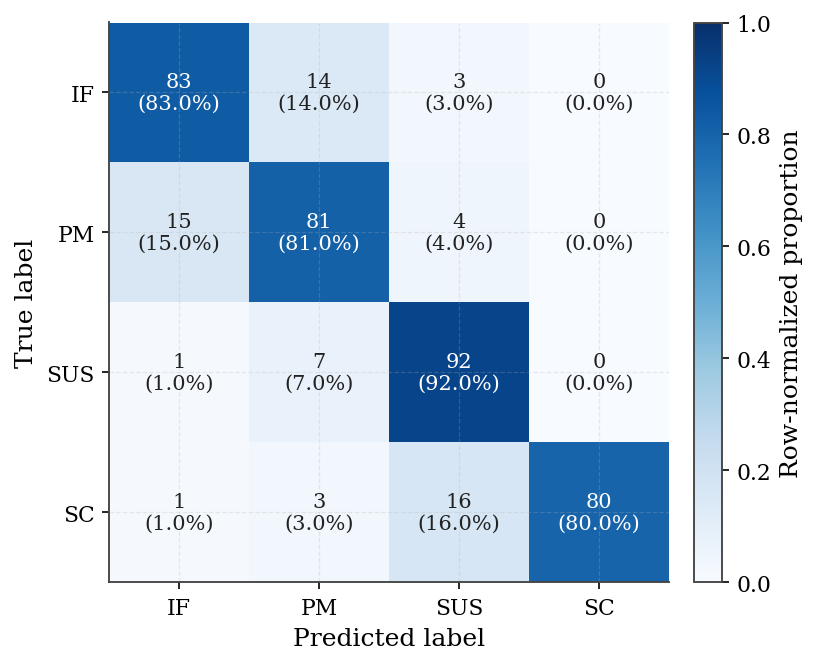

In [19]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mpl.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 600,
    "font.family": "serif", "font.serif": ["Georgia", "Times New Roman", "DejaVu Serif"],
    "font.size": 12, "axes.titlesize": 13, "axes.labelsize": 12,
    "xtick.labelsize": 10.5, "ytick.labelsize": 10.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#444444", "axes.linewidth": 0.9,
    "savefig.bbox": "tight", "savefig.facecolor": "white",
})

# ---- reconciled Stage 2 confusion matrix (Ambiguity-aware fusion) ----
labels = ["IF", "PM", "SUS", "SC"]
cm = np.array([
    [83, 14,  3,  0],
    [15, 81,  4,  0],
    [ 1,  7, 92,  0],
    [ 1,  3, 16, 80],
], dtype=float)

cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5.4, 4.6))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

for i in range(len(labels)):
    for j in range(len(labels)):
        pct = cm_norm[i, j] * 100
        color = "white" if cm_norm[i, j] > 0.55 else "#222222"
        ax.text(j, i, f"{int(cm[i,j])}\n({pct:.1f}%)",
                ha="center", va="center", color=color, fontsize=10)

cbar = fig.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label("Row-normalized proportion")
plt.rcParams["savefig.dpi"] = 600
fig.tight_layout()
fig.savefig("cm_stage2.png")
fig.savefig("cm_stage2.pdf")
print("Saved cm_stage2.png and cm_stage2.pdf")

In [1]:
import os, numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef, roc_auc_score

# ---------------- Setup ----------------
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
print("Device:", DEVICE)

MODELS = "/kaggle/input/datasets/ajfaisal002/misleading-models"
CM_ROOT = "/kaggle/input/datasets/ajfaisal002/crossmodal-misleading-video-dataset"
CM_TXT = os.path.join(CM_ROOT, "dataset_kaggle", "extracted_text")

DIMS = {"vis": 512, "aud": 768, "txl": 768, "tqw": 1024}
SUBMAP = {"identity_fabrication":0, "perception_manipulation":1,
          "scientifically_unrealistic_scene":2, "surreal_content":3}

# ---------------- Load cached features ----------------
def sub_lookup(split):
    df = pd.read_csv(os.path.join(CM_TXT, f"{split}_metadata.csv"))
    return {str(r["video_id"]): SUBMAP.get(r["subcategory"], -1) for _, r in df.iterrows()}
sub_tr, sub_te = sub_lookup("train"), sub_lookup("test")

def load_cm(split, submap):
    d = np.load(os.path.join(MODELS, f"feats_{split}.npz"), allow_pickle=True)
    vids = [str(v) for v in d["vids"]]
    sub = np.array([submap.get(v, -1) for v in vids], dtype=np.int64)
    return {"vis_seq": torch.tensor(d["vis"]), "vis": torch.tensor(d["vis"].mean(1)),
            "aud": torch.tensor(d["aud"]), "txl": torch.tensor(d["txl"]), "tqw": torch.tensor(d["tqw"]),
            "lab": torch.tensor(d["lab"]).long(), "sub": torch.tensor(sub).long()}

CM_TR = load_cm("train", sub_tr)
CM_TE = load_cm("test", sub_te)

def misleading_mask(batch): return batch["sub"] >= 0

print("CM train:", CM_TR["lab"].shape[0], "| CM test:", CM_TE["lab"].shape[0])
print("CM train sub (misleading only):", torch.bincount(CM_TR["sub"][CM_TR["sub"]>=0]).tolist())

# ---------------- Shared building blocks ----------------
class ModalityProj(nn.Module):
    def __init__(self, in_dim, out_dim=384, p=0.4):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, out_dim), nn.LayerNorm(out_dim), nn.GELU(), nn.Dropout(p))
    def forward(self, x): return self.net(x)

class TemporalAttn(nn.Module):
    def __init__(self, dim=512):
        super().__init__(); self.w = nn.Linear(dim, 1)
    def forward(self, seq):
        a = torch.softmax(self.w(seq).squeeze(-1), dim=1)
        return (a.unsqueeze(-1) * seq).sum(1)

class CrossAttn(nn.Module):
    def __init__(self, dim=384, heads=4):
        super().__init__(); self.mha = nn.MultiheadAttention(dim, heads, batch_first=True)
    def forward(self, q, kv):
        q, kv = q.unsqueeze(1), kv.unsqueeze(1)
        o, _ = self.mha(q, kv, kv)
        return o.squeeze(1)

def move(batch, idx=None):
    out = {}
    for k, v in batch.items():
        out[k] = (v[idx] if idx is not None else v).to(DEVICE)
    return out

def compute_metrics(y_true, y_pred, y_prob=None, n_classes=2):
    m = {"Accuracy": accuracy_score(y_true, y_pred)*100,
         "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0)*100,
         "MCC": matthews_corrcoef(y_true, y_pred)}
    if n_classes == 2 and y_prob is not None:
        m["ROC-AUC"] = roc_auc_score(y_true, y_prob)
    elif y_prob is not None:
        try: m["ROC-AUC"] = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
        except Exception: m["ROC-AUC"] = float("nan")
    return m

# ---------------- Ambiguity-aware engine (with M=1 guard) ----------------
class AmbiguityEngine(nn.Module):
    def __init__(self, d, mods):
        super().__init__()
        M = len(mods)
        self.M = M
        if M >= 2:
            n_pairs = M*(M-1)//2
            self.amb_mlp = nn.Sequential(nn.Linear(n_pairs,32), nn.ReLU(), nn.Linear(32,M))
            self.base_cross = CrossAttn(d)
    def forward(self, mats):
        M = len(mats)
        if M < 2:
            return mats[0]
        pairs = []
        for i in range(M):
            for j in range(i+1,M):
                pairs.append((1-F.cosine_similarity(mats[i],mats[j],dim=-1,eps=1e-8)).unsqueeze(1))
        amb_stack = torch.cat(pairs, dim=1)
        adj = torch.softmax(self.amb_mlp(amb_stack), dim=1)
        f_w = sum(adj[:,i:i+1]*mats[i] for i in range(M))
        others = sum(mats[1:])/max(M-1,1)
        base = self.base_cross(mats[0], others) + mats[0]
        return base + f_w

ENGINE_REGISTRY = {"ambiguity": lambda d, mods: AmbiguityEngine(d, mods)}

# ---------------- Pure single-mechanism model (no combine_wgt wrapper) ----------------
class PureEngineModel(nn.Module):
    def __init__(self, mods, engine_name, d=384, dropout=0.4, n_classes=2, use_temporal=True):
        super().__init__()
        self.mods, self.d, self.use_temporal = mods, d, use_temporal
        if "vis" in mods and use_temporal:
            self.tattn = TemporalAttn(512)
        self.proj = nn.ModuleDict({m: ModalityProj(DIMS[m], d, dropout) for m in mods})
        self.engine = ENGINE_REGISTRY[engine_name](d, mods)
        self.head = nn.Sequential(nn.Linear(d,128), nn.LayerNorm(128), nn.GELU(),
                                  nn.Dropout(dropout), nn.Linear(128, n_classes))
    def encode(self, batch):
        feats = {}
        for m in self.mods:
            feats[m] = self.proj[m](self.tattn(batch["vis_seq"])) if (m=="vis" and self.use_temporal) else self.proj[m](batch[m])
        return feats
    def forward(self, batch):
        f = self.encode(batch)
        mats = [f[m] for m in self.mods]
        return self.head(self.engine(mats))

def train_eval_pure(mods, engine_name, train, evalset, n_classes=2, label_key="lab",
                    d=384, dropout=0.4, lr=2e-3, wd=1e-2, epochs=60, bs=64,
                    use_temporal=True, seed=SEED, filter_fn=None):
    torch.manual_seed(seed); np.random.seed(seed)
    model = PureEngineModel(mods, engine_name, d=d, dropout=dropout, n_classes=n_classes,
                            use_temporal=use_temporal).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    lossf = nn.CrossEntropyLoss()
    tr = train
    if filter_fn is not None:
        mask = filter_fn(tr); tr = {k:v[mask] for k,v in tr.items()}
    N = tr[label_key].shape[0]; idx_all = np.arange(N)
    for ep in range(epochs):
        model.train(); np.random.shuffle(idx_all)
        for s in range(0,N,bs):
            b = move(tr, idx_all[s:s+bs])
            loss = lossf(model(b), b[label_key])
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()
    ev = evalset
    if filter_fn is not None:
        mask = filter_fn(ev); ev = {k:v[mask] for k,v in ev.items()}
    model.eval()
    with torch.no_grad():
        b = move(ev); logits = model(b)
        prob = torch.softmax(logits,1).cpu().numpy()
        pred = logits.argmax(1).cpu().numpy(); true = ev[label_key].numpy()
    prob_auc = prob[:,1] if n_classes==2 else prob
    m = compute_metrics(true, pred, prob_auc, n_classes)
    return m, model, (true, pred, prob)

print("\nAll classes/functions ready.\n")

# ---------------- Stage 1 Ablation (reconciled) ----------------
print("=== Stage 1 Ablation — RECONCILED (pure Ambiguity-aware model) ===\n")
abl1 = {"Full":["vis","aud","txl","tqw"], "w/o Audio":["vis","txl","tqw"],
        "w/o Vision":["aud","txl","tqw"], "w/o Text":["vis","aud"]}
for name, mods in abl1.items():
    m, _, _ = train_eval_pure(mods, "ambiguity", CM_TR, CM_TE, n_classes=2, label_key="lab",
                              d=384, dropout=0.4, lr=2e-3, wd=1e-2, epochs=60,
                              use_temporal=("vis" in mods))
    print(f"  {name:12s} Acc={m['Accuracy']:.2f}  MacroF1={m['Macro F1']:.2f}  MCC={m['MCC']:.3f}")

# ---------------- Stage 2 Ablation (reconciled) ----------------
print("\n=== Stage 2 Ablation — RECONCILED (pure Ambiguity-aware model) ===\n")
abl2 = {"Full":["vis","aud","txl","tqw"], "w/o Audio":["vis","txl","tqw"],
        "w/o Vision":["aud","txl","tqw"], "w/o Text":["vis","aud"]}
for name, mods in abl2.items():
    m, _, _ = train_eval_pure(mods, "ambiguity", CM_TR, CM_TE, n_classes=4, label_key="sub",
                              d=384, dropout=0.4, lr=2e-3, wd=1e-2, epochs=60,
                              use_temporal=("vis" in mods), filter_fn=misleading_mask)
    print(f"  {name:12s} Acc={m['Accuracy']:.2f}  MacroF1={m['Macro F1']:.2f}  MCC={m['MCC']:.3f}")

print("\nDONE.")

Device: cuda:0
CM train: 1600 | CM test: 800
CM train sub (misleading only): [200, 200, 200, 200]

All classes/functions ready.

=== Stage 1 Ablation — RECONCILED (pure Ambiguity-aware model) ===

  Full         Acc=85.75  MacroF1=85.75  MCC=0.715
  w/o Audio    Acc=86.50  MacroF1=86.50  MCC=0.730
  w/o Vision   Acc=86.00  MacroF1=86.00  MCC=0.720
  w/o Text     Acc=78.75  MacroF1=78.73  MCC=0.576

=== Stage 2 Ablation — RECONCILED (pure Ambiguity-aware model) ===

  Full         Acc=84.00  MacroF1=84.12  MCC=0.789
  w/o Audio    Acc=84.00  MacroF1=84.21  MCC=0.789
  w/o Vision   Acc=74.75  MacroF1=74.62  MCC=0.664
  w/o Text     Acc=80.00  MacroF1=80.19  MCC=0.736

DONE.


In [14]:
print("hello")

hello
